# Paid Search Campaign Performance Analysis

This project analyses five months of paid search campaign data for an anonymised US shopping mall. The goal is to evaluate campaign efficiency, profitability, and identify opportunities for budget optimisation.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading and Initial Inspection

The dataset is loaded using pandas. Initial checks are performed to review its structure, dimensions, column types, and completeness.

In [30]:

df = pd.read_csv("final_shop_6modata.csv")

In [31]:
df.head()

,Ad Group,Month,Impressions,Clicks,CTR,Conversions,Conv Rate,Cost,CPC,Revenue,Sale Amount,P&L
0,Shop - 1:1 - Desk - [shop coupon code],July,16038,6504,0.41,1166,0.10,6669,1.03,6402,136770.05,-267.086
1,Shop - 1:1 - Desk - [shop coupon],July,36462,14367,0.39,2188,0.09,13746,0.96,13262,283215.21,-483.951
2,Shop - 1:1 - Desk - [shop discount code],July,3635,1458,0.40,248,0.09,1606,1.10,1723,39165.46,117.136
3,Shop - 1:1 - Desk - [shop promo code],July,26185,10418,0.40,2294,0.12,13278,1.27,13042,284823.48,-235.921
4,Shop - 1:1 - Desk - [shop promo],July,808,282,0.35,61,0.15,391,1.39,337,7717.77,-53.604


In [32]:
df.shape

(190, 12)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ad Group     190 non-null    object 
 1   Month        190 non-null    object 
 2   Impressions  190 non-null    int64  
 3   Clicks       190 non-null    int64  
 4   CTR          190 non-null    float64
 5   Conversions  190 non-null    int64  
 6   Conv Rate    190 non-null    float64
 7   Cost         190 non-null    int64  
 8   CPC          190 non-null    float64
 9   Revenue      190 non-null    int64  
 10  Sale Amount  190 non-null    float64
 11  P&L          190 non-null    float64
dtypes: float64(5), int64(5), object(2)
memory usage: 17.9+ KB


## 2. Data Quality Checks

This section checks the dataset for missing values, duplicated records, unexpected categories, and potential inconsistencies before analysis.

In [35]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

print("Unique months:")
display(df["Month"].value_counts())

print("Unique ad groups:", df["Ad Group"].nunique())

Missing values:


Ad Group       0
Month          0
Impressions    0
Clicks         0
CTR            0
Conversions    0
Conv Rate      0
Cost           0
CPC            0
Revenue        0
Sale Amount    0
P&L            0
dtype: int64

Duplicate rows: 0
Unique months:


Month
November     39
July         38
August       38
September    38
October      37
Name: count, dtype: int64

Unique ad groups: 40


In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Impressions,190.0,14077.363158,29771.686227,35.000,1065.0000,4969.000,13380.0000,276568.000
Clicks,190.0,4865.805263,11348.529219,2.000,264.5000,930.000,4190.5000,99526.000
CTR,190.0,0.272105,0.107894,0.050,0.1925,0.285,0.3600,0.470
Conversions,190.0,505.242105,1052.202922,0.000,24.0000,70.500,428.2500,7563.000
Conv Rate,190.0,0.079737,0.052859,0.000,0.0500,0.070,0.1000,0.500
Cost,190.0,3344.063158,6524.606753,1.000,188.5000,563.500,2967.0000,43542.000
CPC,190.0,0.791263,0.403312,0.140,0.4800,0.635,1.1075,2.020
Revenue,190.0,2957.684211,5962.413097,0.000,144.5000,459.500,2672.2500,42440.000
Sale Amount,190.0,63416.180579,125414.656922,0.000,2985.1350,10274.105,59345.1950,886095.310
P&L,190.0,-386.361916,903.073776,-5672.271,-294.9775,-75.978,-6.0275,1507.685


## 3. Metric Validation and Feature Engineering

The dataset already contains CTR, conversion rate, CPC and P&L. These metrics are recalculated from the raw campaign columns to confirm their accuracy. Additional metrics such as CPA, ROAS and profit margin are also created for deeper performance analysis.

In [41]:
# Recalculate supplied metrics
df["Calculated CTR"] = df["Clicks"] / df["Impressions"]
df["Calculated Conv Rate"] = np.where(
    df["Clicks"] > 0,
    df["Conversions"] / df["Clicks"],
    np.nan
)
df["Calculated CPC"] = np.where(
    df["Clicks"] > 0,
    df["Cost"] / df["Clicks"],
    np.nan
)
df["Calculated P&L"] = df["Revenue"] - df["Cost"]

# Create additional performance metrics
df["CPA"] = np.where(
    df["Conversions"] > 0,
    df["Cost"] / df["Conversions"],
    np.nan
)

df["ROAS"] = np.where(
    df["Cost"] > 0,
    df["Revenue"] / df["Cost"],
    np.nan
)

df["Profit Margin"] = np.where(
    df["Revenue"] > 0,
    df["Calculated P&L"] / df["Revenue"],
    np.nan
)

df.head()

,Ad Group,Month,Impressions,Clicks,CTR,Conversions,Conv Rate,Cost,CPC,Revenue,...,Calculated Conv Rate,Calculated CPC,Calculated P&L,CPA,ROAS,Profit Margin,CTR Difference,Conv Rate Difference,CPC Difference,P&L Difference
0,Shop - 1:1 - Desk - [shop coupon code],July,16038,6504,0.41,1166,0.10,6669,1.03,6402,...,0.179274,1.025369,-267,5.719554,0.959964,-0.041706,-0.004463,0.079274,-0.004631,0.086
1,Shop - 1:1 - Desk - [shop coupon],July,36462,14367,0.39,2188,0.09,13746,0.96,13262,...,0.152293,0.956776,-484,6.282450,0.964790,-0.036495,0.004027,0.062293,-0.003224,-0.049
2,Shop - 1:1 - Desk - [shop discount code],July,3635,1458,0.40,248,0.09,1606,1.10,1723,...,0.170096,1.101509,117,6.475806,1.072852,0.067905,0.001100,0.080096,0.001509,-0.136
3,Shop - 1:1 - Desk - [shop promo code],July,26185,10418,0.40,2294,0.12,13278,1.27,13042,...,0.220196,1.274525,-236,5.788143,0.982226,-0.018095,-0.002139,0.100196,0.004525,-0.079
4,Shop - 1:1 - Desk - [shop promo],July,808,282,0.35,61,0.15,391,1.39,337,...,0.216312,1.386525,-54,6.409836,0.861893,-0.160237,-0.000990,0.066312,-0.003475,-0.396


In [42]:
# Calculate differences between supplied and recalculated metrics
df["CTR Difference"] = df["Calculated CTR"] - df["CTR"]
df["Conv Rate Difference"] = df["Calculated Conv Rate"] - df["Conv Rate"]
df["CPC Difference"] = df["Calculated CPC"] - df["CPC"]
df["P&L Difference"] = df["Calculated P&L"] - df["P&L"]

validation_summary = pd.DataFrame({
    "Metric": ["CTR", "Conversion Rate", "CPC", "P&L"],
    "Mean Absolute Difference": [
        df["CTR Difference"].abs().mean(),
        df["Conv Rate Difference"].abs().mean(),
        df["CPC Difference"].abs().mean(),
        df["P&L Difference"].abs().mean()
    ],
    "Maximum Absolute Difference": [
        df["CTR Difference"].abs().max(),
        df["Conv Rate Difference"].abs().max(),
        df["CPC Difference"].abs().max(),
        df["P&L Difference"].abs().max()
    ]
})

validation_summary

,Metric,Mean Absolute Difference,Maximum Absolute Difference
0,CTR,0.002572,0.005000
1,Conversion Rate,0.038021,0.250000
2,CPC,0.008439,0.286667
3,P&L,0.228011,0.499000


### Metric Calcualtion approach

The dataset already contains CTR, conversion rate, CPC and P&L. These metrics were recalculated from the raw campaign columns to confirm their accuracy and identify any inconsistencies.

The following formulas were used:

- **CTR** = Clicks ÷ Impressions
- **Conversion Rate** = Conversions ÷ Clicks
- **CPC** = Cost ÷ Clicks
- **P&L** = Revenue − Cost

Additional performance metrics were also created:

- **CPA** = Cost ÷ Conversions
- **ROAS** = Revenue ÷ Cost
- **Profit Margin** = P&L ÷ Revenue

To prevent division-by-zero errors, missing values were returned where clicks, conversions, cost or revenue were equal to zero.

### Metric Validation Findings

The recalculated CTR, CPC and P&L values closely match the supplied metrics in the dataset.

- **CTR:** The mean absolute difference is 0.0026 and the maximum absolute difference is 0.005. These differences are very small and are most likely caused by the supplied CTR values being rounded to two decimal places.

- **CPC:** The mean absolute difference is 0.0084. This indicates that the supplied CPC values are generally accurate. However, the maximum absolute difference of 0.2867 suggests that at least one row contains a larger inconsistency.

- **P&L:** The mean absolute difference is approximately $0.23, with a maximum absolute difference of about $0.50. These small discrepancies are consistent with rounding in the supplied revenue, cost and P&L values.

- **Conversion Rate:** The mean absolute difference is 0.038, which is equivalent to 3.8 percentage points. The maximum absolute difference is 0.25, or 25 percentage points. This is too large to be explained by normal rounding alone.

The side-by-side comparison also shows that CTR, CPC and P&L remain close to their recalculated values across individual rows. In contrast, conversion-rate differences vary noticeably between ad groups and are often several percentage points apart.

This suggests that the supplied conversion rate may have been calculated using a different denominator or an undocumented conversion definition. Therefore, the recalculated conversion rate, calculated as conversions divided by clicks, will be used throughout the remaining analysis.

### Feature Engineering Summary

The additional metrics provide a clearer view of campaign efficiency and profitability:

- **CPA** measures the average advertising cost required to generate one conversion.
- **ROAS** measures the amount of revenue generated for every dollar spent on advertising.
- **Profit Margin** measures the proportion of revenue remaining after advertising cost.

These recalculated and newly created metrics will be used for the monthly performance analysis, ad-group comparison and budget optimisation recommendations.

## 4. Monthly Performance Analysis

Campaign performance is aggregated by month to evaluate changes in traffic, conversions, spend, revenue and profitability between July and November 2021.

Ratio-based metrics such as CTR, conversion rate, CPC, CPA and ROAS are recalculated from the monthly totals rather than averaged across individual rows. This provides a more accurate view of overall monthly performance.

In [43]:
# Set the correct chronological month order
month_order = ["July", "August", "September", "October", "November"]

df["Month"] = pd.Categorical(
    df["Month"],
    categories=month_order,
    ordered=True
)

# Aggregate the raw campaign metrics by month
monthly_performance = (
    df.groupby("Month", observed=False)
      .agg({
          "Impressions": "sum",
          "Clicks": "sum",
          "Conversions": "sum",
          "Cost": "sum",
          "Revenue": "sum",
          "Calculated P&L": "sum"
      })
      .reset_index()
)

# Recalculate monthly performance metrics from the aggregated totals
monthly_performance["CTR"] = (
    monthly_performance["Clicks"] /
    monthly_performance["Impressions"]
)

monthly_performance["Conversion Rate"] = np.where(
    monthly_performance["Clicks"] > 0,
    monthly_performance["Conversions"] /
    monthly_performance["Clicks"],
    np.nan
)

monthly_performance["CPC"] = np.where(
    monthly_performance["Clicks"] > 0,
    monthly_performance["Cost"] /
    monthly_performance["Clicks"],
    np.nan
)

monthly_performance["CPA"] = np.where(
    monthly_performance["Conversions"] > 0,
    monthly_performance["Cost"] /
    monthly_performance["Conversions"],
    np.nan
)

monthly_performance["ROAS"] = np.where(
    monthly_performance["Cost"] > 0,
    monthly_performance["Revenue"] /
    monthly_performance["Cost"],
    np.nan
)

monthly_performance["Profit Margin"] = np.where(
    monthly_performance["Revenue"] > 0,
    monthly_performance["Calculated P&L"] /
    monthly_performance["Revenue"],
    np.nan
)

monthly_performance

,Month,Impressions,Clicks,Conversions,Cost,Revenue,Calculated P&L,CTR,Conversion Rate,CPC,CPA,ROAS,Profit Margin
0,July,516310,191551,17762,120541,98615,-21926,0.371000,0.092727,0.629289,6.786454,0.818103,-0.222339
1,August,358832,119034,12230,84225,72116,-12109,0.331726,0.102744,0.707571,6.886754,0.856230,-0.167910
2,September,310395,116287,9425,71597,59093,-12504,0.374642,0.081049,0.615692,7.596499,0.825356,-0.211599
3,October,325423,116711,13312,78256,79303,1047,0.358644,0.114060,0.670511,5.878606,1.013379,0.013203
4,November,1163739,380920,43267,280753,252833,-27920,0.327324,0.113586,0.737039,6.488848,0.900553,-0.110429


### Monthly Performance Visualisations

The following charts compare monthly campaign scale, profitability and conversion efficiency.

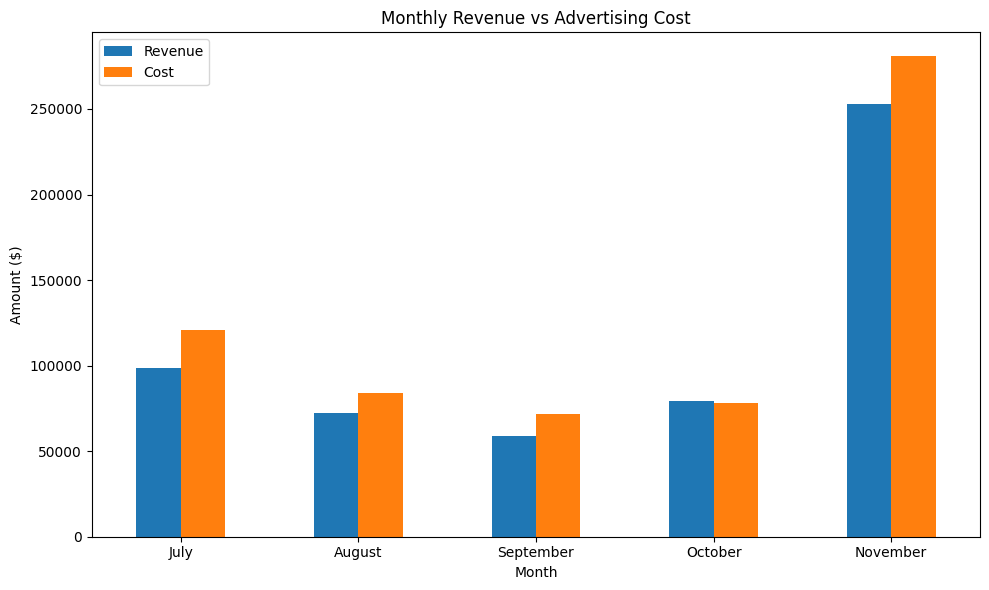

In [45]:
monthly_performance.plot(
    x="Month",
    y=["Revenue", "Cost"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Monthly Revenue vs Advertising Cost")
plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

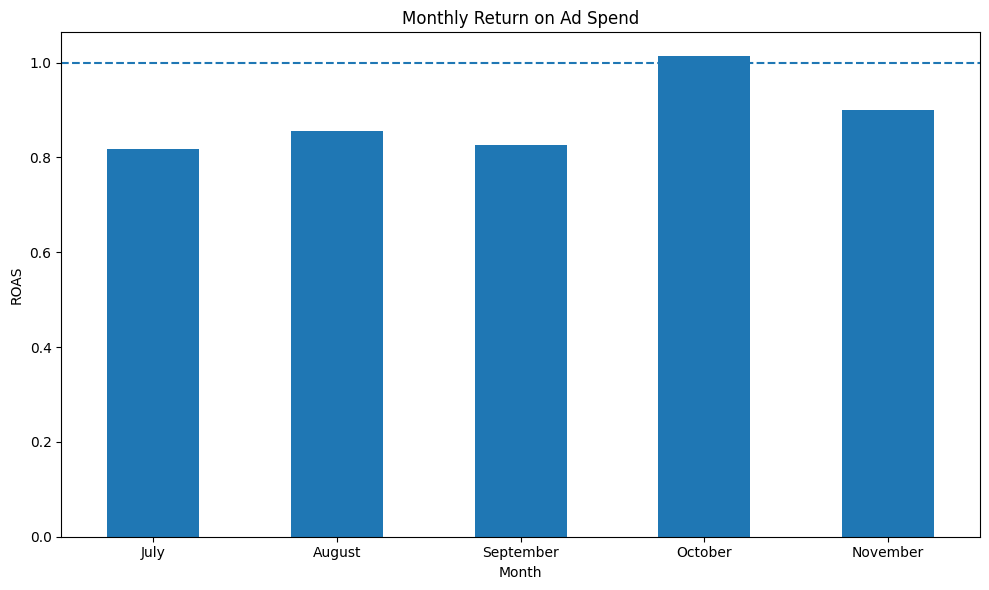

In [46]:
monthly_performance.plot(
    x="Month",
    y="ROAS",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.axhline(1, linestyle="--")
plt.title("Monthly Return on Ad Spend")
plt.xlabel("Month")
plt.ylabel("ROAS")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

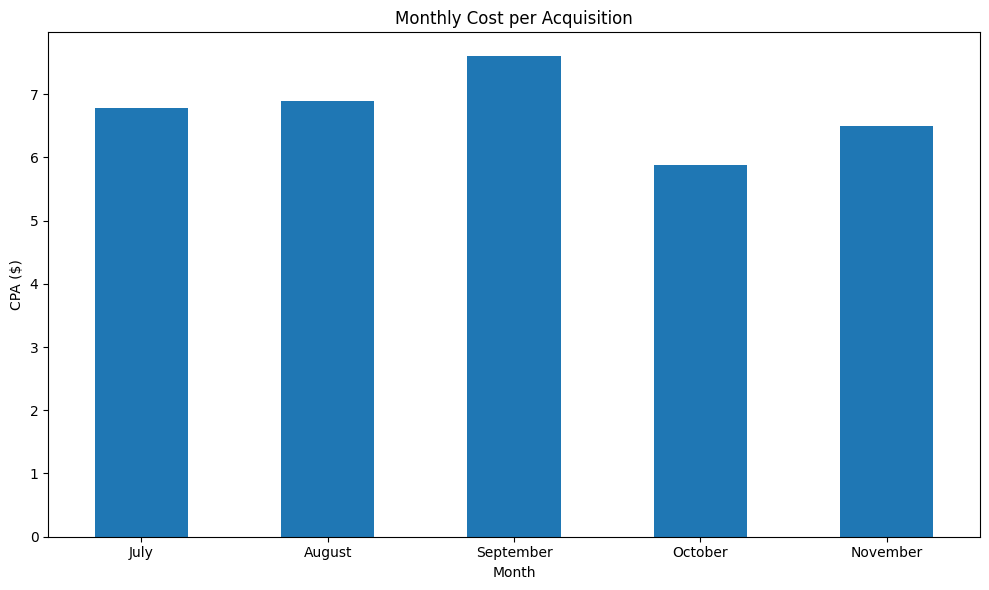

In [47]:
monthly_performance.plot(
    x="Month",
    y="CPA",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("Monthly Cost per Acquisition")
plt.xlabel("Month")
plt.ylabel("CPA ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Monthly Performance Findings

October was the strongest-performing month and the only month to generate a positive financial return. It recorded a P&L of approximately $1,047, a ROAS of 1.01 and a positive profit margin of 1.32%. October also achieved the lowest CPA at approximately $5.88, indicating that conversions were acquired more efficiently than in any other month.

November generated the highest campaign volume, including the most impressions, clicks, conversions, advertising spend and revenue. However, despite this scale, the campaign produced a loss of approximately $27,920 and a ROAS of 0.90. The revenue-versus-cost chart shows that advertising cost remained noticeably higher than revenue, indicating that the increase in campaign scale did not translate into profitable growth.

July recorded the lowest ROAS at approximately 0.82 and a profit margin of -22.23%. The revenue-versus-cost chart also shows a substantial gap between advertising spend and revenue, making July one of the weakest months from a profitability perspective.

September recorded the lowest conversion rate at approximately 8.10% and the highest CPA at approximately $7.60. This suggests that the traffic generated during September was less effective at producing conversions.

November achieved the highest conversion rate at approximately 11.36%. However, its higher CPC and significantly larger advertising spend reduced overall profitability. This shows that a strong conversion rate alone does not guarantee a profitable campaign.

The ROAS chart confirms that October was the only month above the break-even level of 1.0. The CPA chart also reinforces October's stronger efficiency, while September had the highest acquisition cost.

Overall, the monthly analysis shows that higher traffic, conversion volume and revenue did not necessarily result in stronger financial performance. October delivered the best balance between campaign scale, conversion efficiency and profitability.

## 5. Ad Group Performance Analysis

This section compares performance across ad groups to identify the strongest revenue generators, the most profitable segments, high-spend underperformers and opportunities for budget reallocation.

In [48]:
# Aggregate performance by ad group
ad_group_performance = (
    df.groupby("Ad Group")
      .agg({
          "Impressions": "sum",
          "Clicks": "sum",
          "Conversions": "sum",
          "Cost": "sum",
          "Revenue": "sum",
          "Calculated P&L": "sum"
      })
      .reset_index()
)

# Recalculate ratio-based metrics from aggregated totals
ad_group_performance["CTR"] = (
    ad_group_performance["Clicks"] /
    ad_group_performance["Impressions"]
)

ad_group_performance["Conversion Rate"] = np.where(
    ad_group_performance["Clicks"] > 0,
    ad_group_performance["Conversions"] /
    ad_group_performance["Clicks"],
    np.nan
)

ad_group_performance["CPC"] = np.where(
    ad_group_performance["Clicks"] > 0,
    ad_group_performance["Cost"] /
    ad_group_performance["Clicks"],
    np.nan
)

ad_group_performance["CPA"] = np.where(
    ad_group_performance["Conversions"] > 0,
    ad_group_performance["Cost"] /
    ad_group_performance["Conversions"],
    np.nan
)

ad_group_performance["ROAS"] = np.where(
    ad_group_performance["Cost"] > 0,
    ad_group_performance["Revenue"] /
    ad_group_performance["Cost"],
    np.nan
)

ad_group_performance["Profit Margin"] = np.where(
    ad_group_performance["Revenue"] > 0,
    ad_group_performance["Calculated P&L"] /
    ad_group_performance["Revenue"],
    np.nan
)

ad_group_performance.head()

,Ad Group,Impressions,Clicks,Conversions,Cost,Revenue,Calculated P&L,CTR,Conversion Rate,CPC,CPA,ROAS,Profit Margin
0,Shop - 1:1 - Desk - [shop coupon code],87936,33805,6094,41194,37147,-4047,0.384427,0.180269,1.218577,6.759764,0.901758,-0.108946
1,Shop - 1:1 - Desk - [shop coupon],183886,66619,10232,69198,60317,-8881,0.362284,0.153590,1.038713,6.762901,0.871658,-0.147239
2,Shop - 1:1 - Desk - [shop discount code],18326,7015,1269,8605,8405,-200,0.382789,0.180898,1.226657,6.780930,0.976758,-0.023795
3,Shop - 1:1 - Desk - [shop promo code],142526,54312,12439,81485,74305,-7180,0.381067,0.229029,1.500313,6.550768,0.911886,-0.096629
4,Shop - 1:1 - Desk - [shop promo],5572,1710,348,2474,2290,-184,0.306892,0.203509,1.446784,7.109195,0.925627,-0.080349


In [49]:
top_profit = ad_group_performance.nlargest(
    10,
    "Calculated P&L"
)

top_roas = ad_group_performance[
    ad_group_performance["Cost"] >= 1000
].nlargest(
    10,
    "ROAS"
)

highest_spend_losses = ad_group_performance[
    ad_group_performance["Calculated P&L"] < 0
].nlargest(
    10,
    "Cost"
)

display(top_profit)
display(top_roas)
display(highest_spend_losses)

,Ad Group,Impressions,Clicks,Conversions,Cost,Revenue,Calculated P&L,CTR,Conversion Rate,CPC,CPA,ROAS,Profit Margin
18,Shop - Exact - Mob - Black Friday/Cyber Monday,3662,266,24,44,160,116,0.072638,0.090226,0.165414,1.833333,3.636364,0.725000
33,Shop - Phrase - Mob - Competitor,330,77,10,41,87,46,0.233333,0.129870,0.532468,4.100000,2.121951,0.528736
10,Shop - Exact - Desk - Black Friday/Cyber Monday,257,24,7,3,45,42,0.093385,0.291667,0.125000,0.428571,15.000000,0.933333
29,Shop - Phrase - Desk - Free Shipping,342,38,3,17,28,11,0.111111,0.078947,0.447368,5.666667,1.647059,0.392857
26,Shop - Phrase - Desk - Competitor,109,10,2,7,13,6,0.091743,0.200000,0.700000,3.500000,1.857143,0.461538
14,Shop - Exact - Desk - Free Shipping,4095,900,139,362,346,-16,0.219780,0.154444,0.402222,2.604317,0.955801,-0.046243
36,Shop - Phrase - Mob - Free Shipping,636,109,5,30,11,-19,0.171384,0.045872,0.275229,6.000000,0.366667,-1.727273
16,Shop - Exact - Desk - Promo Code,51253,16814,3592,23846,23821,-25,0.328059,0.213631,1.418223,6.638641,0.998952,-0.001049
23,Shop - Exact - Mob - Offer,11549,2542,195,1559,1484,-75,0.220106,0.076711,0.613297,7.994872,0.951892,-0.050539
11,Shop - Exact - Desk - Competitor,3969,905,119,932,810,-122,0.228017,0.131492,1.029834,7.831933,0.869099,-0.150617


,Ad Group,Impressions,Clicks,Conversions,Cost,Revenue,Calculated P&L,CTR,Conversion Rate,CPC,CPA,ROAS,Profit Margin
16,Shop - Exact - Desk - Promo Code,51253,16814,3592,23846,23821,-25,0.328059,0.213631,1.418223,6.638641,0.998952,-0.001049
2,Shop - 1:1 - Desk - [shop discount code],18326,7015,1269,8605,8405,-200,0.382789,0.180898,1.226657,6.780930,0.976758,-0.023795
23,Shop - Exact - Mob - Offer,11549,2542,195,1559,1484,-75,0.220106,0.076711,0.613297,7.994872,0.951892,-0.050539
24,Shop - Exact - Mob - Promo Code,107057,40152,4084,25398,24164,-1234,0.375053,0.101713,0.632546,6.218903,0.951413,-0.051068
31,Shop - Phrase - Desk - Promo Code,61144,15065,2905,19618,18640,-978,0.246386,0.192831,1.302224,6.753184,0.950148,-0.052468
8,Shop - 1:1 - Mob - [shop promo code],304202,132203,16174,93570,88171,-5399,0.434590,0.122342,0.707775,5.785211,0.942300,-0.061233
12,Shop - Exact - Desk - Coupon Code,43171,13508,2121,14709,13742,-967,0.312895,0.157018,1.088910,6.934936,0.934258,-0.070368
4,Shop - 1:1 - Desk - [shop promo],5572,1710,348,2474,2290,-184,0.306892,0.203509,1.446784,7.109195,0.925627,-0.080349
9,Shop - 1:1 - Mob - [shop promo],12153,4268,454,2634,2404,-230,0.351189,0.106373,0.617151,5.801762,0.912680,-0.095674
3,Shop - 1:1 - Desk - [shop promo code],142526,54312,12439,81485,74305,-7180,0.381067,0.229029,1.500313,6.550768,0.911886,-0.096629


,Ad Group,Impressions,Clicks,Conversions,Cost,Revenue,Calculated P&L,CTR,Conversion Rate,CPC,CPA,ROAS,Profit Margin
8,Shop - 1:1 - Mob - [shop promo code],304202,132203,16174,93570,88171,-5399,0.434590,0.122342,0.707775,5.785211,0.942300,-0.061233
6,Shop - 1:1 - Mob - [shop coupon],719140,267398,14022,91497,76475,-15022,0.371830,0.052439,0.342175,6.525246,0.835820,-0.196430
3,Shop - 1:1 - Desk - [shop promo code],142526,54312,12439,81485,74305,-7180,0.381067,0.229029,1.500313,6.550768,0.911886,-0.096629
1,Shop - 1:1 - Desk - [shop coupon],183886,66619,10232,69198,60317,-8881,0.362284,0.153590,1.038713,6.762901,0.871658,-0.147239
5,Shop - 1:1 - Mob - [shop coupon code],234766,102347,9546,59272,52946,-6326,0.435953,0.093271,0.579128,6.209093,0.893272,-0.119480
0,Shop - 1:1 - Desk - [shop coupon code],87936,33805,6094,41194,37147,-4047,0.384427,0.180269,1.218577,6.759764,0.901758,-0.108946
24,Shop - Exact - Mob - Promo Code,107057,40152,4084,25398,24164,-1234,0.375053,0.101713,0.632546,6.218903,0.951413,-0.051068
16,Shop - Exact - Desk - Promo Code,51253,16814,3592,23846,23821,-25,0.328059,0.213631,1.418223,6.638641,0.998952,-0.001049
20,Shop - Exact - Mob - Coupon Code,131273,45441,2905,20100,17534,-2566,0.346156,0.063929,0.442332,6.919105,0.872338,-0.146344
31,Shop - Phrase - Desk - Promo Code,61144,15065,2905,19618,18640,-978,0.246386,0.192831,1.302224,6.753184,0.950148,-0.052468


### Ad Group Ranking Approach

Some ad groups generated positive returns from very small levels of spend. Although these groups recorded high ROAS, their limited campaign volume makes them less reliable for budget decisions.

To focus the analysis on commercially meaningful performance, a minimum advertising spend of $1,000 is applied when ranking scalable ad groups. Small-volume groups are retained as potential testing opportunities rather than immediate candidates for significant budget increases.

In [50]:
# Focus on ad groups with commercially meaningful spend
scalable_ad_groups = ad_group_performance[
    ad_group_performance["Cost"] >= 1000
].copy()

# Best-performing scalable ad groups by ROAS
best_scalable_groups = scalable_ad_groups.nlargest(
    10,
    "ROAS"
)

# Largest losses among scalable ad groups
largest_loss_groups = scalable_ad_groups.nsmallest(
    10,
    "Calculated P&L"
)

# Small-volume profitable groups worth further testing
test_opportunities = ad_group_performance[
    (ad_group_performance["Calculated P&L"] > 0) &
    (ad_group_performance["Cost"] < 1000)
].nlargest(
    10,
    "ROAS"
)

display(best_scalable_groups)
display(largest_loss_groups)
display(test_opportunities)

,Ad Group,Impressions,Clicks,Conversions,Cost,Revenue,Calculated P&L,CTR,Conversion Rate,CPC,CPA,ROAS,Profit Margin
16,Shop - Exact - Desk - Promo Code,51253,16814,3592,23846,23821,-25,0.328059,0.213631,1.418223,6.638641,0.998952,-0.001049
2,Shop - 1:1 - Desk - [shop discount code],18326,7015,1269,8605,8405,-200,0.382789,0.180898,1.226657,6.780930,0.976758,-0.023795
23,Shop - Exact - Mob - Offer,11549,2542,195,1559,1484,-75,0.220106,0.076711,0.613297,7.994872,0.951892,-0.050539
24,Shop - Exact - Mob - Promo Code,107057,40152,4084,25398,24164,-1234,0.375053,0.101713,0.632546,6.218903,0.951413,-0.051068
31,Shop - Phrase - Desk - Promo Code,61144,15065,2905,19618,18640,-978,0.246386,0.192831,1.302224,6.753184,0.950148,-0.052468
8,Shop - 1:1 - Mob - [shop promo code],304202,132203,16174,93570,88171,-5399,0.434590,0.122342,0.707775,5.785211,0.942300,-0.061233
12,Shop - Exact - Desk - Coupon Code,43171,13508,2121,14709,13742,-967,0.312895,0.157018,1.088910,6.934936,0.934258,-0.070368
4,Shop - 1:1 - Desk - [shop promo],5572,1710,348,2474,2290,-184,0.306892,0.203509,1.446784,7.109195,0.925627,-0.080349
9,Shop - 1:1 - Mob - [shop promo],12153,4268,454,2634,2404,-230,0.351189,0.106373,0.617151,5.801762,0.912680,-0.095674
3,Shop - 1:1 - Desk - [shop promo code],142526,54312,12439,81485,74305,-7180,0.381067,0.229029,1.500313,6.550768,0.911886,-0.096629


,Ad Group,Impressions,Clicks,Conversions,Cost,Revenue,Calculated P&L,CTR,Conversion Rate,CPC,CPA,ROAS,Profit Margin
6,Shop - 1:1 - Mob - [shop coupon],719140,267398,14022,91497,76475,-15022,0.371830,0.052439,0.342175,6.525246,0.835820,-0.196430
1,Shop - 1:1 - Desk - [shop coupon],183886,66619,10232,69198,60317,-8881,0.362284,0.153590,1.038713,6.762901,0.871658,-0.147239
3,Shop - 1:1 - Desk - [shop promo code],142526,54312,12439,81485,74305,-7180,0.381067,0.229029,1.500313,6.550768,0.911886,-0.096629
5,Shop - 1:1 - Mob - [shop coupon code],234766,102347,9546,59272,52946,-6326,0.435953,0.093271,0.579128,6.209093,0.893272,-0.119480
8,Shop - 1:1 - Mob - [shop promo code],304202,132203,16174,93570,88171,-5399,0.434590,0.122342,0.707775,5.785211,0.942300,-0.061233
0,Shop - 1:1 - Desk - [shop coupon code],87936,33805,6094,41194,37147,-4047,0.384427,0.180269,1.218577,6.759764,0.901758,-0.108946
25,Shop - Exact - Mob - Sale,46474,5038,182,3732,1090,-2642,0.108405,0.036125,0.740770,20.505495,0.292069,-2.423853
20,Shop - Exact - Mob - Coupon Code,131273,45441,2905,20100,17534,-2566,0.346156,0.063929,0.442332,6.919105,0.872338,-0.146344
38,Shop - Phrase - Mob - Promo Code,81574,20554,1578,12058,9645,-2413,0.251968,0.076773,0.586650,7.641318,0.799884,-0.250181
34,Shop - Phrase - Mob - Coupon Code,42180,14081,839,7183,5168,-2015,0.333831,0.059584,0.510120,8.561383,0.719477,-0.389899


,Ad Group,Impressions,Clicks,Conversions,Cost,Revenue,Calculated P&L,CTR,Conversion Rate,CPC,CPA,ROAS,Profit Margin
10,Shop - Exact - Desk - Black Friday/Cyber Monday,257,24,7,3,45,42,0.093385,0.291667,0.125000,0.428571,15.000000,0.933333
18,Shop - Exact - Mob - Black Friday/Cyber Monday,3662,266,24,44,160,116,0.072638,0.090226,0.165414,1.833333,3.636364,0.725000
33,Shop - Phrase - Mob - Competitor,330,77,10,41,87,46,0.233333,0.129870,0.532468,4.100000,2.121951,0.528736
26,Shop - Phrase - Desk - Competitor,109,10,2,7,13,6,0.091743,0.200000,0.700000,3.500000,1.857143,0.461538
29,Shop - Phrase - Desk - Free Shipping,342,38,3,17,28,11,0.111111,0.078947,0.447368,5.666667,1.647059,0.392857


### Ad Group Performance Visualisations

The following charts compare scalable ad groups, major loss-making segments and small-volume profitable groups that may justify further testing.

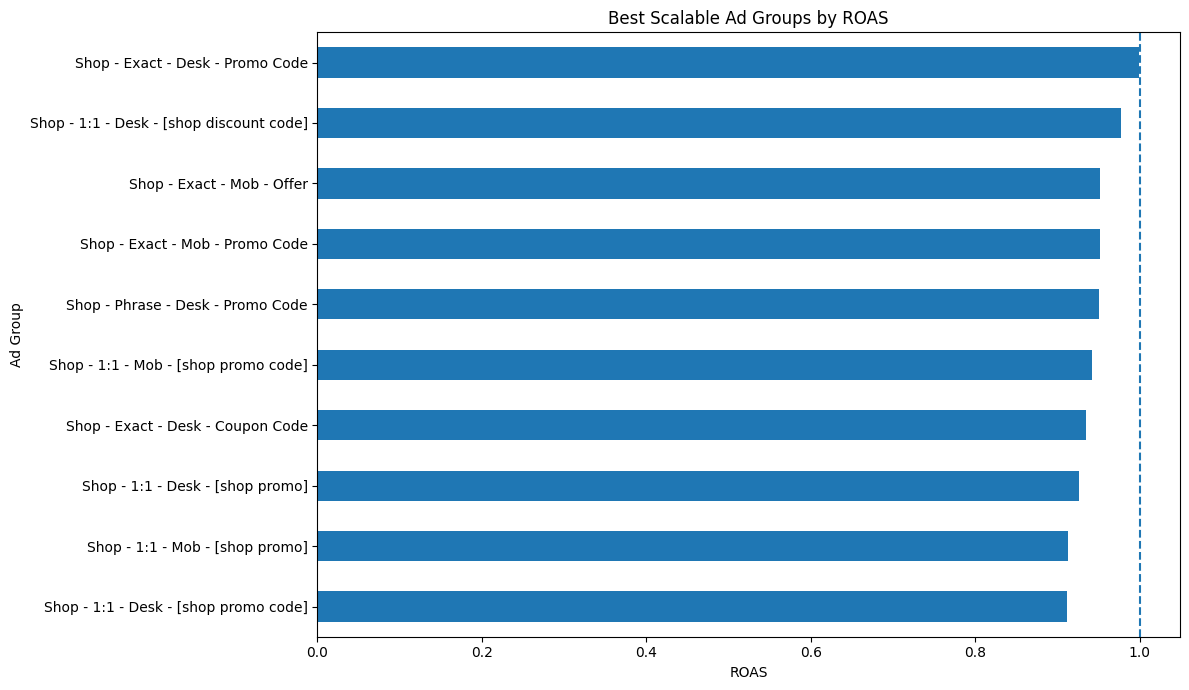

In [51]:
best_scalable_plot = best_scalable_groups.sort_values("ROAS")

best_scalable_plot.plot(
    x="Ad Group",
    y="ROAS",
    kind="barh",
    figsize=(12, 7),
    legend=False
)

plt.axvline(1, linestyle="--")
plt.title("Best Scalable Ad Groups by ROAS")
plt.xlabel("ROAS")
plt.ylabel("Ad Group")
plt.tight_layout()
plt.show()

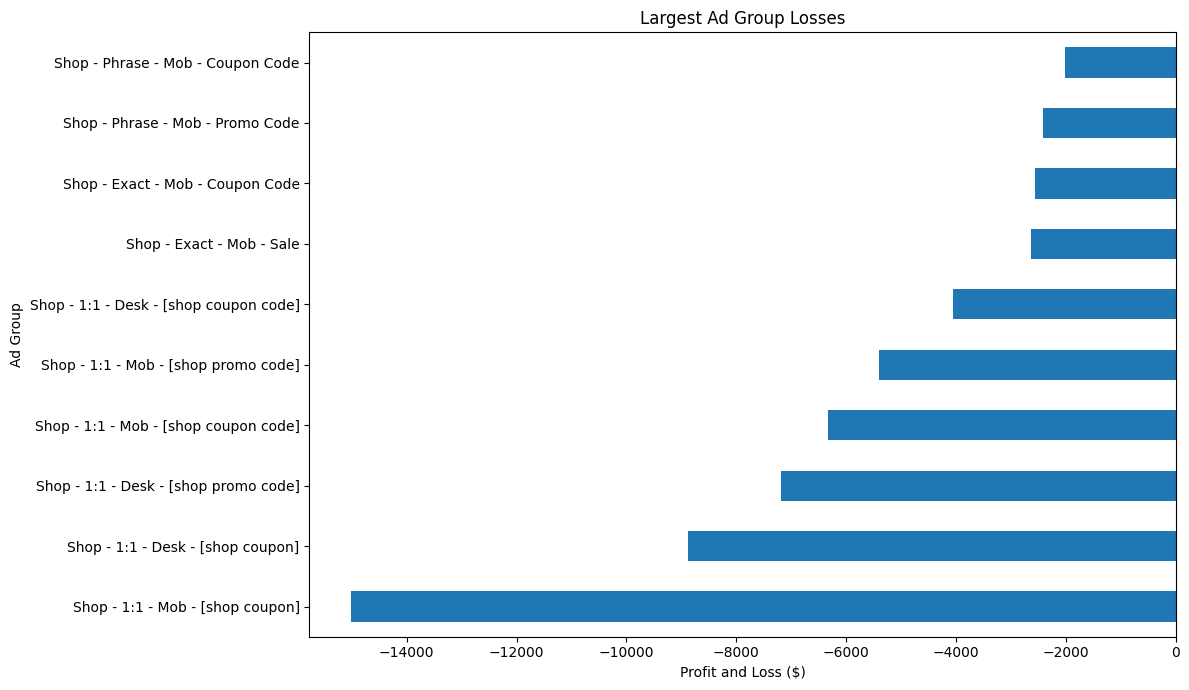

In [52]:
largest_losses_plot = largest_loss_groups.sort_values("Calculated P&L")

largest_losses_plot.plot(
    x="Ad Group",
    y="Calculated P&L",
    kind="barh",
    figsize=(12, 7),
    legend=False
)

plt.title("Largest Ad Group Losses")
plt.xlabel("Profit and Loss ($)")
plt.ylabel("Ad Group")
plt.tight_layout()
plt.show()

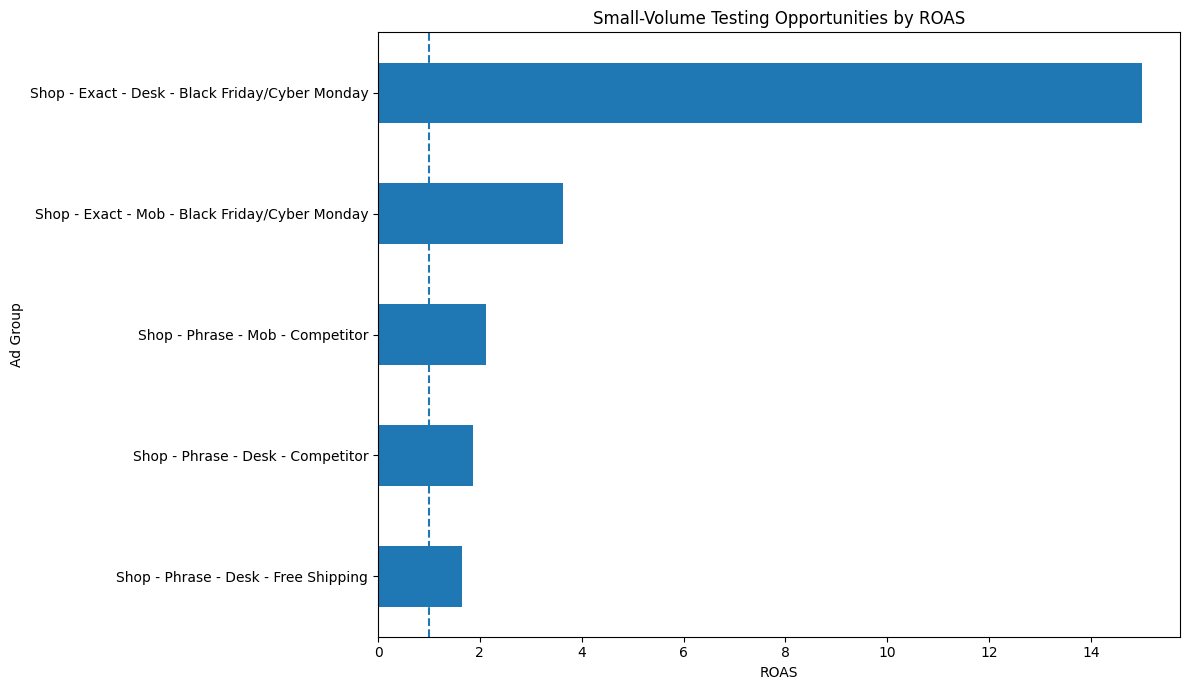

In [53]:
test_opportunities_plot = test_opportunities.sort_values("ROAS")

test_opportunities_plot.plot(
    x="Ad Group",
    y="ROAS",
    kind="barh",
    figsize=(12, 7),
    legend=False
)

plt.axvline(1, linestyle="--")
plt.title("Small-Volume Testing Opportunities by ROAS")
plt.xlabel("ROAS")
plt.ylabel("Ad Group")
plt.tight_layout()
plt.show()

### Ad Group Performance Findings

The scalable ad-group analysis shows that no ad group with at least $1,000 in advertising spend achieved a ROAS above 1.0. This means that none of the higher-spend ad groups generated more revenue than advertising cost over the full campaign period.

The strongest scalable ad group was **Shop – Exact – Desk – Promo Code**, with a ROAS of approximately 1.00. It generated $23,821 in revenue from $23,846 in spend, producing a loss of only $25. This group was effectively break-even and should be prioritised for careful optimisation rather than immediate budget reduction.

The largest source of loss was **Shop – 1:1 – Mob – [shop coupon]**, which lost approximately $15,022. Other significant loss-making groups included:

- **Shop – 1:1 – Desk – [shop coupon]**, with a loss of approximately $8,881.
- **Shop – 1:1 – Desk – [shop promo code]**, with a loss of approximately $7,180.
- **Shop – 1:1 – Mob – [shop coupon code]**, with a loss of approximately $6,326.
- **Shop – 1:1 – Mob – [shop promo code]**, with a loss of approximately $5,399.

The largest-loss chart shows that campaign losses were concentrated in high-volume 1:1 coupon and promo-code ad groups. These groups generated substantial traffic and conversion volume, but their revenue remained below advertising cost.

Several small-volume ad groups generated positive returns. The strongest was **Shop – Exact – Desk – Black Friday/Cyber Monday**, with a ROAS of 15.00. The mobile version of the same seasonal term achieved a ROAS of approximately 3.64.

Other profitable low-volume groups included competitor and free-shipping terms. However, these results were based on very small levels of spend and conversion volume. Their high ROAS values should therefore be interpreted cautiously.

These groups should be treated as controlled testing opportunities rather than immediate candidates for large budget increases. Budgets could be raised gradually while monitoring whether ROAS, CPA and conversion rate remain stable as spend increases.

Overall, the analysis suggests that the campaign relied too heavily on large, loss-making coupon-focused ad groups, while the strongest efficiency appeared in smaller exact-match, seasonal and competitor-related segments.

## 6. Budget Optimisation Recommendations

This section converts the monthly and ad-group findings into practical recommendations for reducing wasted spend, protecting near-break-even activity and testing higher-potential segments.

In [54]:
# Create budget recommendation categories
def assign_budget_action(row):
    if row["Cost"] < 1000 and row["ROAS"] > 1:
        return "Test with gradual budget increase"

    elif row["ROAS"] >= 0.98:
        return "Protect and optimise"

    elif row["ROAS"] >= 0.90:
        return "Reduce budget and improve efficiency"

    else:
        return "Significantly reduce or pause"


ad_group_performance["Budget Action"] = ad_group_performance.apply(
    assign_budget_action,
    axis=1
)

# Create a concise recommendation table
budget_recommendations = ad_group_performance[
    [
        "Ad Group",
        "Cost",
        "Revenue",
        "Calculated P&L",
        "Conversions",
        "CPA",
        "ROAS",
        "Budget Action"
    ]
].sort_values(
    ["Budget Action", "Calculated P&L"]
)

budget_recommendations

,Ad Group,Cost,Revenue,Calculated P&L,Conversions,CPA,ROAS,Budget Action
16,Shop - Exact - Desk - Promo Code,23846,23821,-25,3592,6.638641,0.998952,Protect and optimise
3,Shop - 1:1 - Desk - [shop promo code],81485,74305,-7180,12439,6.550768,0.911886,Reduce budget and improve efficiency
8,Shop - 1:1 - Mob - [shop promo code],93570,88171,-5399,16174,5.785211,0.942300,Reduce budget and improve efficiency
0,Shop - 1:1 - Desk - [shop coupon code],41194,37147,-4047,6094,6.759764,0.901758,Reduce budget and improve efficiency
24,Shop - Exact - Mob - Promo Code,25398,24164,-1234,4084,6.218903,0.951413,Reduce budget and improve efficiency
31,Shop - Phrase - Desk - Promo Code,19618,18640,-978,2905,6.753184,0.950148,Reduce budget and improve efficiency
12,Shop - Exact - Desk - Coupon Code,14709,13742,-967,2121,6.934936,0.934258,Reduce budget and improve efficiency
27,Shop - Phrase - Desk - Coupon Code,9995,9101,-894,1411,7.083629,0.910555,Reduce budget and improve efficiency
9,Shop - 1:1 - Mob - [shop promo],2634,2404,-230,454,5.801762,0.912680,Reduce budget and improve efficiency
2,Shop - 1:1 - Desk - [shop discount code],8605,8405,-200,1269,6.780930,0.976758,Reduce budget and improve efficiency


In [55]:
action_summary = (
    ad_group_performance.groupby("Budget Action")
    .agg({
        "Ad Group": "count",
        "Cost": "sum",
        "Revenue": "sum",
        "Calculated P&L": "sum",
        "Conversions": "sum"
    })
    .rename(columns={"Ad Group": "Number of Ad Groups"})
    .reset_index()
)

action_summary["ROAS"] = (
    action_summary["Revenue"] /
    action_summary["Cost"]
)

action_summary

,Budget Action,Number of Ad Groups,Cost,Revenue,Calculated P&L,Conversions,ROAS
0,Protect and optimise,1,23846,23821,-25,3592,0.998952
1,Reduce budget and improve efficiency,12,301603,280199,-21404,47633,0.929033
2,Significantly reduce or pause,22,309811,257607,-52204,44725,0.831497
3,Test with gradual budget increase,5,112,333,221,46,2.973214


### Budget Optimisation Findings

The recommendation framework shows that the majority of campaign spend was concentrated in underperforming ad groups.

The **Significantly reduce or pause** category contained 22 ad groups and accounted for approximately $309,811 in advertising spend. These groups generated about $257,607 in revenue, resulting in a combined loss of approximately $52,204 and a ROAS of 0.83. This category represents the largest opportunity to reduce wasted spend.

The **Reduce budget and improve efficiency** category contained 12 ad groups and accounted for approximately $301,603 in spend. These groups generated about $280,199 in revenue, producing a combined loss of approximately $21,404 and a ROAS of 0.93. These ad groups may still be recoverable through tighter keyword targeting, bid adjustments, search-term exclusions, improved ad relevance and landing-page optimisation.

Only one ad group was classified as **Protect and optimise**. This group generated $23,821 in revenue from $23,846 in spend, resulting in a loss of only $25 and a ROAS of approximately 1.00. It should remain active while being carefully optimised toward profitability.

Five low-volume ad groups were classified as **Test with gradual budget increase**. Together, they generated $333 in revenue from only $112 in spend, producing $221 in profit and a combined ROAS of 2.97. However, these results were achieved at very low spend levels and should be treated as early evidence rather than proof of scalability.

The recommended strategy is to reduce investment in the weakest ad groups, protect the near-break-even activity and redirect a small portion of budget toward controlled tests of the profitable low-volume segments. Any budget increases should be gradual and reviewed against ROAS, CPA, conversion rate and profit after additional spend is introduced.

## 7. Key Findings and Conclusion

This project analysed five months of paid search campaign data from July to November 2021 to evaluate campaign efficiency, profitability and opportunities for budget optimisation.

### Key Findings

- **October was the strongest month** and the only month to achieve a positive financial return. It generated a ROAS of approximately 1.01, a profit of about $1,047 and the lowest monthly CPA at approximately $5.88.

- **November generated the highest campaign volume**, including the most impressions, clicks, conversions, spend and revenue. However, it produced a loss of approximately $27,920, showing that higher scale did not result in profitable growth.

- **September had the weakest conversion efficiency**, recording the lowest conversion rate and the highest CPA.

- The supplied CTR, CPC and P&L values closely matched the recalculated metrics. However, the supplied conversion rate showed larger inconsistencies, so the recalculated conversion rate was used throughout the analysis.

- **No ad group with at least $1,000 in spend was profitable.** The strongest scalable ad group was Shop – Exact – Desk – Promo Code, which was effectively break-even with a ROAS of approximately 1.00.

- The largest losses were concentrated in high-volume 1:1 coupon and promo-code ad groups. Shop – 1:1 – Mob – [shop coupon] generated the largest individual loss at approximately $15,022.

- Several seasonal, competitor and free-shipping ad groups generated positive returns. However, these results were based on very small levels of spend and should be treated as testing opportunities rather than proven scalable performers.

- The budget recommendation framework identified 22 ad groups that should be significantly reduced or paused. These groups accounted for approximately $309,811 in spend and a combined loss of approximately $52,204.

### Recommendations

The campaign should reduce investment in the weakest high-spend ad groups, particularly the underperforming coupon-focused segments. Near-break-even activity should remain active while being optimised through bid adjustments, keyword refinement, negative keywords, ad-copy testing and landing-page improvements.

A small portion of the recovered budget should be redirected toward controlled testing of profitable low-volume segments. These tests should use gradual budget increases and be monitored closely to determine whether strong ROAS and conversion efficiency remain stable at higher spend levels.

Monthly performance should also be reviewed regularly because October demonstrated that the campaign could operate close to profitability when spend, conversion efficiency and acquisition cost were better balanced.

### Conclusion

The analysis shows that campaign growth should not be evaluated using traffic, conversions or revenue alone. November produced the highest campaign volume but also the largest monthly loss, while October delivered the strongest financial performance at a smaller scale.

The clearest optimisation opportunity is to reduce wasted spend in consistently unprofitable ad groups, protect near-break-even activity and test higher-potential segments gradually. This approach would improve budget efficiency while reducing the risk of scaling results that are not yet supported by sufficient campaign volume.